# Tema 4 - Spark SQL y Procesamiento de Datos

Ejemplo práctico usando el dataset `employees_dataset_with_missing.csv` (open-datasets), con columnas numéricas y valores nulos: `age`, `income`, `education_years`, `experience`, `credit_score`.

Contenido:
1. Fundamentos de Spark SQL (vistas temporales + SQL nativo)
2. Operaciones con DataFrames (select, filter, groupBy)
3. Funciones integradas para tratamiento de nulos
4. LAB: limpieza, agregación y visualización (EDA)

In [11]:
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Requiere winutils.exe en HADOOP_HOME\bin (necesario en Windows)
os.environ["HADOOP_HOME"] = r"C:\hadoop\winutils\hadoop-3.3.6"
os.environ["hadoop.home.dir"] = os.environ["HADOOP_HOME"]
os.environ["PATH"] = os.path.join(os.environ["HADOOP_HOME"], "bin") + ";" + os.environ["PATH"]

# Reinicia el kernel antes de ejecutar esta celda si vienes de otro notebook con Spark ya iniciado
spark = SparkSession.builder.appName("EDA_Empleados").getOrCreate()

In [12]:
csv_path = "./open-datasets/employees_dataset_with_missing.csv"
df_emp = spark.read.csv(csv_path, header=True, inferSchema=True)

df_emp.printSchema()
df_emp.show(5)

root
 |-- age: double (nullable = true)
 |-- income: double (nullable = true)
 |-- education_years: double (nullable = true)
 |-- experience: double (nullable = true)
 |-- credit_score: double (nullable = true)

+------------------+-----------------+------------------+-------------------+-----------------+
|               age|           income|   education_years|         experience|     credit_score|
+------------------+-----------------+------------------+-------------------+-----------------+
|              NULL|70990.33154879004|11.974465175076855|0.46096221061304554|563.6506395035066|
| 33.61735698828815|63869.50524369153|13.566443987853447|  5.698074946102491|646.8796511060916|
| 41.47688538100692|50894.45554880261|11.622740237000116|  7.931972332891778|651.8016872044446|
| 50.23029856408026|40295.94833441639| 13.07611541108288|  19.43843828670095|697.2630345843405|
|32.658466252766644|60473.34970420385| 8.319155999138644|  12.78276562266879|513.3141636719174|
+------------------+

## 1. Fundamentos de Spark SQL

Registramos el DataFrame como vista temporal para poder consultarlo con SQL nativo.

In [13]:
df_emp.createOrReplaceTempView("empleados")

spark.sql("""
    SELECT
        COUNT(*) AS total_filas,
        AVG(income) AS income_medio,
        AVG(credit_score) AS credit_score_medio
    FROM empleados
""").show()

+-----------+-----------------+------------------+
|total_filas|     income_medio|credit_score_medio|
+-----------+-----------------+------------------+
|       1000|51060.01732721878| 645.0726360597142|
+-----------+-----------------+------------------+



## 2. Operaciones con DataFrames

Selección/derivación de columnas, filtrado y agrupación usando la DataFrame API.

In [14]:
# Derivamos una columna categórica a partir de 'experience'
df_derivado = df_emp.select(
    F.col("age"), F.col("income"), F.col("experience"), F.col("credit_score")
).withColumn(
    "nivel_experiencia",
    F.when(F.col("experience") < 5, "Junior")
     .when(F.col("experience") < 15, "Mid")
     .otherwise("Senior")
)
df_derivado.show(10)

+------------------+-----------------+-------------------+------------------+-----------------+
|               age|           income|         experience|      credit_score|nivel_experiencia|
+------------------+-----------------+-------------------+------------------+-----------------+
|              NULL|70990.33154879004|0.46096221061304554| 563.6506395035066|           Junior|
| 33.61735698828815|63869.50524369153|  5.698074946102491| 646.8796511060916|              Mid|
| 41.47688538100692|50894.45554880261|  7.931972332891778| 651.8016872044446|              Mid|
| 50.23029856408026|40295.94833441639|  19.43843828670095| 697.2630345843405|           Senior|
|32.658466252766644|60473.34970420385|  12.78276562266879| 513.3141636719174|              Mid|
|  32.6586304305082|55902.28078132625| 3.3225921545005432|  709.256727384733|           Junior|
| 50.79212815507391|63427.89830041598| 12.430181447088184|379.56083683972247|              Mid|
| 42.67434729152909|59527.57702522954| 2

In [15]:
# Filtrado: empleados con ingresos por encima de 50000
df_filtrado = df_derivado.filter(F.col("income") > 50000)
print(f"Filas tras filtrar income > 50000: {df_filtrado.count()}")
df_filtrado.show(5)

Filas tras filtrar income > 50000: 446
+------------------+-----------------+-------------------+-----------------+-----------------+
|               age|           income|         experience|     credit_score|nivel_experiencia|
+------------------+-----------------+-------------------+-----------------+-----------------+
|              NULL|70990.33154879004|0.46096221061304554|563.6506395035066|           Junior|
| 33.61735698828815|63869.50524369153|  5.698074946102491|646.8796511060916|              Mid|
| 41.47688538100692|50894.45554880261|  7.931972332891778|651.8016872044446|              Mid|
|32.658466252766644|60473.34970420385|  12.78276562266879|513.3141636719174|              Mid|
|  32.6586304305082|55902.28078132625| 3.3225921545005432| 709.256727384733|           Junior|
+------------------+-----------------+-------------------+-----------------+-----------------+
only showing top 5 rows


In [16]:
# Agrupación: ingreso medio y credit_score medio por nivel de experiencia
df_agrupado = df_filtrado.groupBy("nivel_experiencia").agg(
    F.round(F.avg("income"), 2).alias("income_medio"),
    F.round(F.avg("credit_score"), 2).alias("credit_score_medio"),
    F.count("*").alias("num_empleados")
)
df_agrupado.orderBy("nivel_experiencia").show()

+-----------------+------------+------------------+-------------+
|nivel_experiencia|income_medio|credit_score_medio|num_empleados|
+-----------------+------------+------------------+-------------+
|           Junior|    62099.55|            640.65|           72|
|              Mid|    62791.43|            645.32|          255|
|           Senior|     61421.4|            631.19|          119|
+-----------------+------------+------------------+-------------+



## 3. Funciones integradas: tratamiento de valores nulos

In [17]:
# Conteo de nulos por columna antes de limpiar
df_emp.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_emp.columns
]).show()

+---+------+---------------+----------+------------+
|age|income|education_years|experience|credit_score|
+---+------+---------------+----------+------------+
|116|   149|             91|       127|           0|
+---+------+---------------+----------+------------+



In [18]:
# Limpieza: eliminamos filas totalmente vacías, rellenamos nulos puntuales
# y usamos coalesce como alternativa más flexible a fillna
df_clean = df_emp.dropna(how="all") \
    .fillna({
        "income": 0.0,
        "credit_score": 300
    }) \
    .withColumn("age", F.coalesce(F.col("age"), F.lit(0))) \
    .withColumn("experience", F.coalesce(F.col("experience"), F.lit(0)))

df_clean.show(5)

+------------------+-----------------+------------------+-------------------+-----------------+
|               age|           income|   education_years|         experience|     credit_score|
+------------------+-----------------+------------------+-------------------+-----------------+
|               0.0|70990.33154879004|11.974465175076855|0.46096221061304554|563.6506395035066|
| 33.61735698828815|63869.50524369153|13.566443987853447|  5.698074946102491|646.8796511060916|
| 41.47688538100692|50894.45554880261|11.622740237000116|  7.931972332891778|651.8016872044446|
| 50.23029856408026|40295.94833441639| 13.07611541108288|  19.43843828670095|697.2630345843405|
|32.658466252766644|60473.34970420385| 8.319155999138644|  12.78276562266879|513.3141636719174|
+------------------+-----------------+------------------+-------------------+-----------------+
only showing top 5 rows


## 4. LAB: Análisis Exploratorio (EDA) y visualización final

Sobre los datos ya limpios, calculamos el ingreso medio agrupado por rango de edad y lo representamos en un gráfico de barras.

In [19]:
# Creamos rangos de edad (bucketing) y agregamos el ingreso medio por rango
df_rangos = df_clean.withColumn(
    "rango_edad",
    F.when(F.col("age") < 25, "< 25")
     .when(F.col("age") < 35, "25-34")
     .when(F.col("age") < 45, "35-44")
     .when(F.col("age") < 55, "45-54")
     .otherwise("55+")
).withColumn(
    # Orden numérico auxiliar: orderBy sobre texto pondría "< 25" al final (alfabéticamente)
    "orden_rango",
    F.when(F.col("age") < 25, 1)
     .when(F.col("age") < 35, 2)
     .when(F.col("age") < 45, 3)
     .when(F.col("age") < 55, 4)
     .otherwise(5)
)

df_resumen = df_rangos.groupBy("rango_edad", "orden_rango").agg(
    F.round(F.avg("income"), 2).alias("income_medio"),
    F.count("*").alias("num_empleados")
).orderBy("orden_rango").drop("orden_rango")

df_resumen.show()

+----------+------------+-------------+
|rango_edad|income_medio|num_empleados|
+----------+------------+-------------+
|      < 25|    44511.13|          245|
|     25-34|    43161.01|          304|
|     35-44|    43549.33|          313|
|     45-54|    43147.93|          115|
|       55+|     36215.1|           23|
+----------+------------+-------------+



### Agregaciones avanzadas: función de ventana

Usando `Window.partitionBy`, obtenemos, dentro de cada rango de edad, los 3 empleados con mayor ingreso.

In [21]:
from pyspark.sql.window import Window

# Ventana: partición independiente por cada rango de edad, ordenada por ingreso descendente
window_spec = Window.partitionBy("rango_edad").orderBy(F.desc("income"))

df_top3_por_rango = df_rangos.withColumn(
    "ranking", F.rank().over(window_spec)
).filter(F.col("ranking") <= 3)

df_top3_por_rango.select(
    "rango_edad", "ranking", "age", "income", "credit_score"
).orderBy("rango_edad", "ranking").show(20)

+----------+-------+------------------+------------------+------------------+
|rango_edad|ranking|               age|            income|      credit_score|
+----------+-------+------------------+------------------+------------------+
|     25-34|      1| 28.48399652394183| 88695.64006481477| 700.4483256383016|
|     25-34|      2|30.069990653411672| 87394.99276149186| 606.9690680045358|
|     25-34|      3| 34.65288230294757| 86051.23377857413| 625.7301252174718|
|     35-44|      1|36.292211819752275| 97896.61351767291| 619.0350286011939|
|     35-44|      2|39.567532191537836| 97066.22800489991| 756.0089739908666|
|     35-44|      3| 39.40014450053332| 89665.15020525552| 604.0235384169524|
|     45-54|      1| 49.79944138890026| 88372.98928502378| 554.2431044984788|
|     45-54|      2| 47.77676821898509| 82475.03517351625|400.19389825070607|
|     45-54|      3|46.950466289248425|  81111.2400462496| 694.7393937068975|
|       55+|      1| 61.32382064837391| 70604.87817744436| 679.4

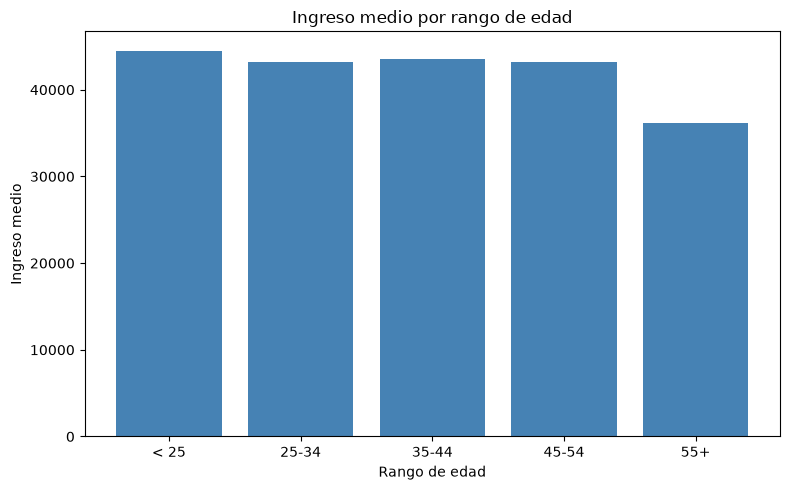

In [20]:
import matplotlib.pyplot as plt

# Convertimos el resultado ya agregado (pocas filas) a pandas para graficarlo
pdf_resumen = df_resumen.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(pdf_resumen["rango_edad"], pdf_resumen["income_medio"], color="steelblue")
plt.title("Ingreso medio por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Ingreso medio")
plt.tight_layout()
plt.show()